In [1]:
# Install everything the notebook needs (safe to re-run).
%pip install -q transformers torch sentencepiece ddgs wikipedia langgraph matplotlib networkx

Note: you may need to restart the kernel to use updated packages.


e:\git_projects\NLP\.venv\Scripts\python.exe: No module named pip


## Assignment 1 — Build Your Own Simple Agent

Two tools + a Thought → Action → Observation → Answer loop. `search_tool` uses
DuckDuckGo (`ddgs`) with a Wikipedia and local-corpus fallback so it works offline;
`calculator_tool` safely evaluates arithmetic.

In [2]:
import re

# A tiny offline knowledge base used when the network is unavailable.
LOCAL_FACTS = {
    "germany gdp": "Germany's GDP in 2023 was about 4.4 trillion USD (nominal).",
    "france gdp": "France's GDP in 2023 was about 3.1 trillion USD (nominal).",
    "capital of france": "The capital of France is Paris.",
    "speed of light": "The speed of light is about 299,792 kilometres per second.",
}


def search_tool(query: str) -> str:
    """Web search via DuckDuckGo; fall back to Wikipedia, then a local corpus."""
    # 1) DuckDuckGo
    try:
        from ddgs import DDGS
        with DDGS() as ddgs:
            hits = [r["title"] + ". " + r["body"]
                    for r in ddgs.text(query, max_results=3)]
        if hits:
            return " ".join(hits)[:600]
    except Exception as e:
        print(f"  (ddgs unavailable: {type(e).__name__}; trying fallbacks)")
    # 2) Wikipedia
    try:
        import wikipedia
        return wikipedia.summary(query, sentences=3)
    except Exception:
        pass
    # 3) Local corpus
    q = query.lower()
    for key, fact in LOCAL_FACTS.items():
        if all(w in q for w in key.split()):
            return fact
    return "No result found."


def calculator_tool(expr: str) -> str:
    """Safely evaluate an arithmetic expression (digits and + - * / ( ) only)."""
    if not re.fullmatch(r"[0-9\.\+\-\*\/\(\) ]+", expr):
        return "Calculator error: invalid expression."
    try:
        return str(eval(expr))
    except Exception as e:
        return f"Calculator error: {e}"


print(calculator_tool("(4.4 - 3.1) * 1000"))
print(search_tool("capital of France"))

def looks_like_math(text: str) -> bool:
    return bool(re.search(r"\d", text)) and bool(re.search(r"[\+\-\*/]", text))


1300.0000000000002
  (ddgs unavailable: ModuleNotFoundError; trying fallbacks)
The capital of France is Paris.


### Thought → Action → Observation → Answer loop

A lightweight **router** decides which tool to use (a calculator if the query looks
like math, otherwise search), then `Qwen2.5-1.5B-Instruct` turns the observation into a final
natural-language answer.

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Qwen2.5-1.5B-Instruct: public (Apache-2.0), so NO Hugging Face token/login,
# and it actually follows instructions. Loaded directly with transformers.
_name = "Qwen/Qwen2.5-1.5B-Instruct"
_tok = AutoTokenizer.from_pretrained(_name)
_model = AutoModelForCausalLM.from_pretrained(_name, torch_dtype="auto", low_cpu_mem_usage=True)


def llm(prompt):
    """Run Qwen via its chat template and return [{'generated_text': ...}] so the
    rest of the notebook (llm(prompt)[0]['generated_text']) works unchanged."""
    messages = [{"role": "user", "content": prompt}]
    text = _tok.apply_chat_template(messages, tokenize=False,
                                    add_generation_prompt=True)
    inputs = _tok(text, return_tensors="pt")
    out = _model.generate(inputs.input_ids, attention_mask=inputs.attention_mask, max_new_tokens=80, do_sample=False)
    reply = _tok.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)  # new text only
    return [{"generated_text": reply.strip()}]



def agent(query: str, verbose: bool = True) -> str:
    log = []
    # THOUGHT
    if looks_like_math(query):
        thought = "This is a calculation -> use calculator_tool."
        action = ("calculator", re.sub(r"[^0-9\.\+\-\*\/\(\) ]", "", query))
    else:
        thought = "This needs facts -> use search_tool."
        action = ("search", query)
    log.append(("Thought", thought))
    log.append(("Action", f"{action[0]}({action[1]!r})"))

    # ACTION + OBSERVATION
    observation = (calculator_tool if action[0] == "calculator" else search_tool)(action[1])
    log.append(("Observation", observation[:300]))

    # ANSWER: math -> return the exact computed result;
    #         facts -> let the (tiny) LLM phrase the observation.
    if action[0] == "calculator":
        answer = observation
    else:
        prompt = (f"Question: {query}\n"
                  f"Information: {observation}\n"
                  f"Give a short, direct answer.")
        answer = llm(prompt)[0]["generated_text"].strip()
    log.append(("Answer", answer))

    if verbose:
        for tag, val in log:
            print(f"{tag}: {val}")
        print("-" * 60)
    return answer


agent("What is the capital of France?")
agent("What is 24 * (7 + 3)?")

e:\git_projects\NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.
e:\git_projects\NLP\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\wargh\.cache\huggingface\hub\models--Qwen--Qwen2.5-1.5B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either nee

  (ddgs unavailable: ModuleNotFoundError; trying fallbacks)


e:\git_projects\NLP\.venv\Lib\site-packages\transformers\generation\configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
e:\git_projects\NLP\.venv\Lib\site-packages\transformers\generation\configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
e:\git_projects\NLP\.venv\Lib\site-packages\transformers\generation\configuration_utils.py:653: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


Thought: This needs facts -> use search_tool.
Action: search('What is the capital of France?')
Observation: The capital of France is Paris.
Answer: Paris
------------------------------------------------------------
Thought: This is a calculation -> use calculator_tool.
Action: calculator('  24 * (7 + 3)')
Observation: 240
Answer: 240
------------------------------------------------------------


'240'

## Assignment 2 — Add Memory to Your Agent

A simple list-based conversation memory (LangChain-style `ConversationBufferMemory`)
so the agent recalls earlier turns and can answer follow-ups.

In [4]:
# A plain list is all the "memory" we need: each item is "Role: text".
memory = []


def agent_with_memory(query: str) -> str:
    recalled = "\n".join(memory[-4:])          # last few turns for context
    if looks_like_math(query):
        answer = calculator_tool(re.sub(r"[^0-9\.\+\-\*\/\(\) ]", "", query))
    else:
        prompt = (f"Conversation so far:\n{recalled}\n\n"
                  f"Question: {query}\nAnswer using the conversation above.")
        answer = llm(prompt)[0]["generated_text"].strip()
        answer = answer.removeprefix("Agent:").removeprefix("User:").strip()
    memory.append(f"User: {query}")
    memory.append(f"Agent: {answer}")
    return answer


print("Turn 1:", agent_with_memory("My name is Yash Annapure, nice to meet you!"))
print("Turn 2:", agent_with_memory("What is 2 * 2?"))
print("Turn 3:", agent_with_memory("Remind me, what was my name again?"))
print("\n--- Memory buffer ---")
print("\n".join(memory))

Turn 1: Hello, Yash Annapure! Nice to meet you too! How can I assist you today?
Turn 2: 4
Turn 3: Your name is Yash Annapure.

--- Memory buffer ---
User: My name is Yash Annapure, nice to meet you!
Agent: Hello, Yash Annapure! Nice to meet you too! How can I assist you today?
User: What is 2 * 2?
Agent: 4
User: Remind me, what was my name again?
Agent: Your name is Yash Annapure.


## Assignment 3 — Multi-Agent Collaboration

Three specialised agents coordinated by a sequential controller:

- **SearchAgent** — retrieves facts.
- **AnalysisAgent** — reasons / computes over them.
- **ReportAgent** — writes a human-readable summary.

In [5]:
def search_agent(task: str) -> str:
    print("  [SearchAgent] retrieving...")
    return search_tool(task)


def analysis_agent(text: str) -> str:
    print("  [AnalysisAgent] analysing...")
    nums = re.findall(r"[0-9]+(?:\.[0-9]+)?", text)
    note = f"Found {len(nums)} numeric facts: {nums[:5]}." if nums else "No numbers found."
    prompt = f"Extract the single most important fact from:\n{text}\nKey fact:"
    key = llm(prompt)[0]["generated_text"].strip()
    return f"{note} Key fact: {key}"


def report_agent(topic: str, findings: str, analysis: str) -> str:
    print("  [ReportAgent] writing report...")
    prompt = (f"Write a 2-sentence report about '{topic}'.\n"
              f"Findings: {findings}\nAnalysis: {analysis}")
    return llm(prompt)[0]["generated_text"].strip()


def orchestrate(topic: str) -> str:
    print(f"COORDINATOR: handling '{topic}'")
    findings = search_agent(topic)
    analysis = analysis_agent(findings)
    report = report_agent(topic, findings, analysis)
    print("-" * 60)
    return report


print("\nFINAL REPORT:\n", orchestrate("renewable energy in Germany"))

COORDINATOR: handling 'renewable energy in Germany'
  [SearchAgent] retrieving...
  (ddgs unavailable: ModuleNotFoundError; trying fallbacks)
  [AnalysisAgent] analysing...
  [ReportAgent] writing report...
------------------------------------------------------------

FINAL REPORT:
 The analysis reveals that no relevant results were found for "renewable energy in Germany." This suggests that either there isn't sufficient data on this topic or it hasn't been adequately researched and reported upon. Without specific figures or statistics, it's challenging to provide detailed insights into renewable energy sources in Germany.


## Assignment 4 — Orchestration with LangGraph (+ conditional branch)

Rebuild the multi-agent flow as a **LangGraph** state machine. A **router** node
adds a conditional branch:

> if the topic is about **finance** → `FinanceAgent`; else → `GeneralAgent`.

Both branches converge on a shared `ReportAgent`.

In [ ]:
from typing import TypedDict, Optional
from langgraph.graph import StateGraph, END


class AgentState(TypedDict, total=False):
    topic: str
    route: str
    findings: str
    report: str


def router_node(state: AgentState):
    topic = state["topic"].lower()
    finance_words = ("finance", "gdp", "stock", "market", "economy", "inflation",
                     "investment", "bank")
    route = "finance" if any(w in topic for w in finance_words) else "general"
    print(f"[Router] topic -> {route}")
    return {"route": route}


def finance_agent(state: AgentState):
    print("[FinanceAgent] specialised financial lookup")
    return {"findings": search_tool(state["topic"] + " economy finance")}


def general_agent(state: AgentState):
    print("[GeneralAgent] general-purpose lookup")
    return {"findings": search_tool(state["topic"])}


def report_node(state: AgentState):
    print("[ReportAgent] summarising")
    prompt = f"Summarise this about '{state['topic']}' in one sentence:\n{state['findings']}"
    return {"report": llm(prompt)[0]["generated_text"].strip()}


def pick_branch(state: AgentState):
    return state["route"]          # "finance" or "general"


workflow = StateGraph(AgentState)
workflow.add_node("router", router_node)
workflow.add_node("finance", finance_agent)
workflow.add_node("general", general_agent)
workflow.add_node("report", report_node)

workflow.set_entry_point("router")
workflow.add_conditional_edges("router", pick_branch,
                               {"finance": "finance", "general": "general"})
workflow.add_edge("finance", "report")
workflow.add_edge("general", "report")
workflow.add_edge("report", END)

graph = workflow.compile()
print("graph compiled\n")

### Run both branches

In [60]:
for topic in ["GDP growth of Germany", "renewable energy adoption"]:
    print(f"===== TOPIC: {topic} =====")
    result = graph.invoke({"topic": topic})
    print("REPORT:", result["report"], "\n")

===== TOPIC: GDP growth of Germany =====
[Router] topic -> finance
[FinanceAgent] specialised financial lookup
[ReportAgent] summarising
REPORT: Germany's nominal GDP ranks third globally with an increase of 0.8% in 2026 and is expected to grow further at 1.2% in 2027, according to data from various sources including Trading Economics and the World Bank. 

===== TOPIC: renewable energy adoption =====
[Router] topic -> general
[GeneralAgent] general-purpose lookup
[ReportAgent] summarising
REPORT: Costa Rica's success in generating nearly all of its electricity from renewable sources like hydropower, wind, and geothermal energy serves as an inspiring example for other developing countries aiming to adopt renewable energy more widely. 



### Visualize the orchestration graph

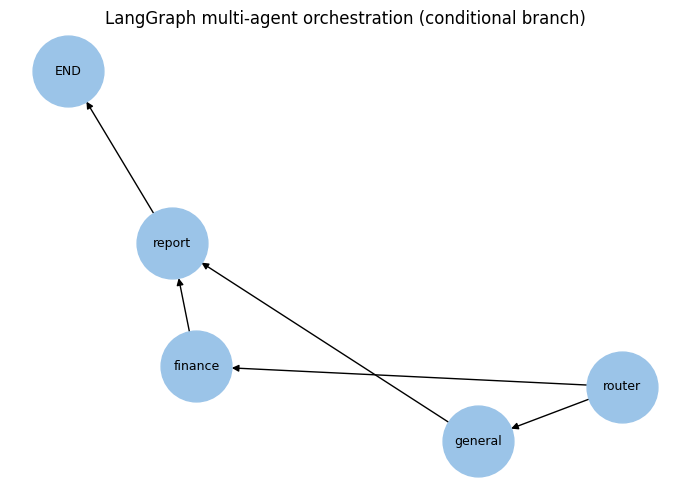

In [61]:
import matplotlib.pyplot as plt
import networkx as nx

g = nx.DiGraph()
g.add_edges_from([
    ("router", "finance"), ("router", "general"),
    ("finance", "report"), ("general", "report"), ("report", "END"),
])
plt.figure(figsize=(7, 5))
pos = nx.spring_layout(g, seed=7)
nx.draw_networkx(g, pos, with_labels=True, node_color="#9BC4E8",
                 node_size=2600, font_size=9, arrows=True)
plt.title("LangGraph multi-agent orchestration (conditional branch)")
plt.axis("off")
plt.tight_layout()
plt.show()

### Reflection

- **Agent loop:** even without a giant LLM, the *Thought → Action → Observation →
  Answer* structure plus a tool router gives reliable, inspectable behaviour.
- **Memory** turns isolated calls into a conversation; a list buffer is enough for
  small agents, vector memory for larger ones.
- **Multi-agent** decomposition (search / analyse / report) keeps each component
  simple and testable.
- **LangGraph** makes the control flow explicit and adds **conditional routing**
  (finance vs general), which is hard to express cleanly with plain function calls.
